<a href="https://colab.research.google.com/github/Pramit44/Alfido-Tech-Data-Science-Internship-Project/blob/main/Loan_Approval_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import glob
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report
import warnings
warnings.filterwarnings('ignore')


In [ ]:
path = kagglehub.dataset_download("bhanupratapbiswas/loan-approval-prediction-case-study")
csv_file=glob.glob(path+'/*.csv')[0]
df=pd.read_csv(csv_file)
df.head(10)

Using Colab cache for faster access to the 'loan-approval-prediction-case-study' dataset.


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


Exploratory Data Analysis


In [ ]:
df.shape

(614, 13)

In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 67.2+ KB


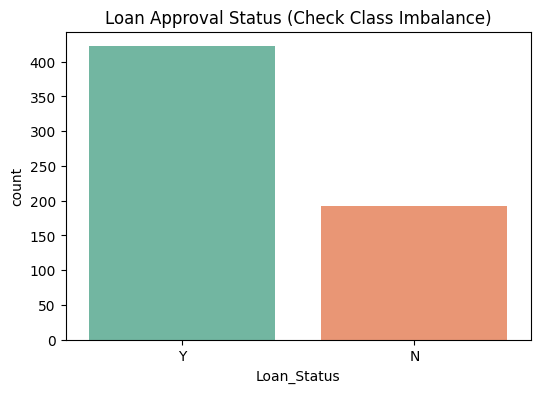

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Loan_Status', palette='Set2')
plt.title("Loan Approval Status (Check Class Imbalance)")
plt.show()

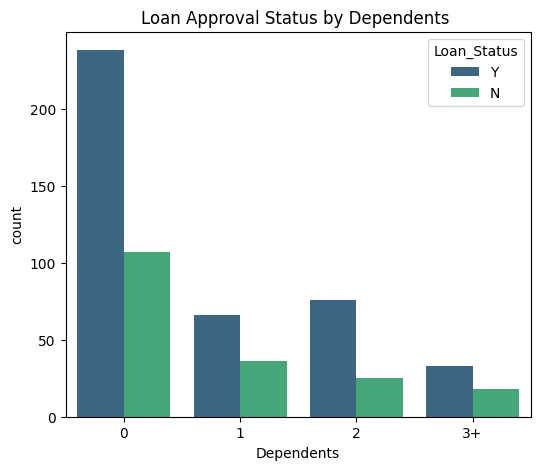

In [ ]:
plt.figure(figsize=(6, 5))
sns.countplot(df,x="Dependents",hue="Loan_Status",palette='viridis')
plt.title("Loan Approval Status by Dependents ")
plt.show()

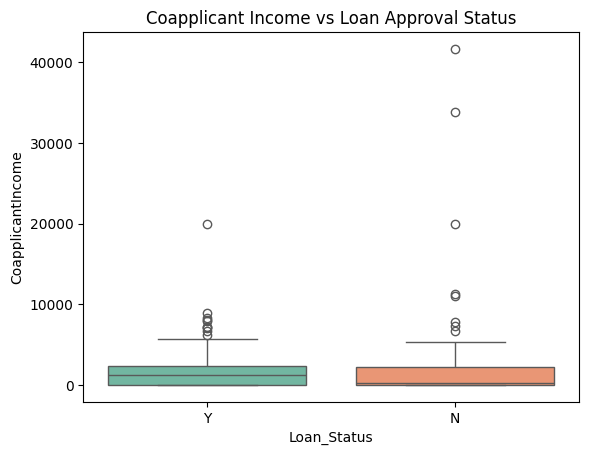

In [ ]:
sns.boxplot(data=df, x='Loan_Status', y='CoapplicantIncome', palette='Set2')
plt.title("Coapplicant Income vs Loan Approval Status")
plt.show()


Text(0.5, 1.0, 'Distribution of Coapplicant Income')

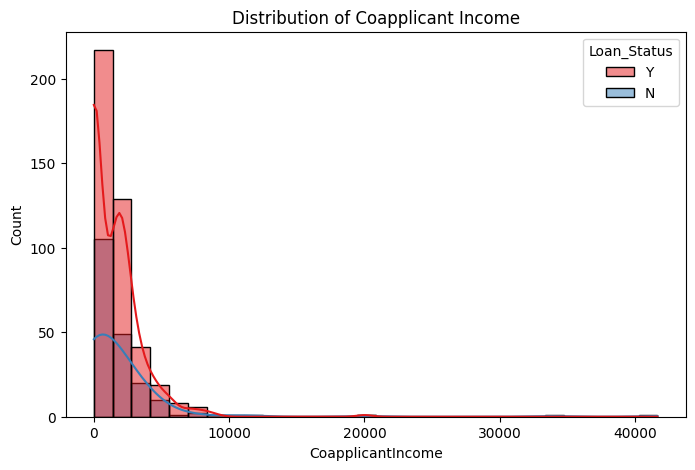

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='CoapplicantIncome', hue='Loan_Status', kde=True, bins=30, palette='Set1')
plt.title("Distribution of Coapplicant Income")

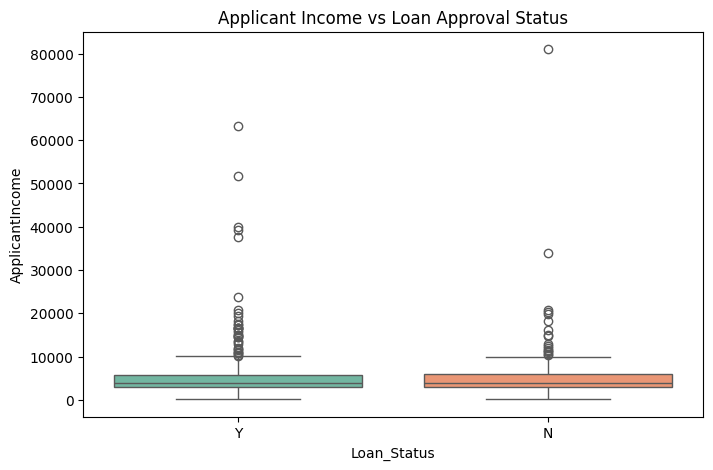

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Loan_Status', y='ApplicantIncome', palette='Set2')
plt.title("Applicant Income vs Loan Approval Status")
plt.show()

Data Preprocessing

In [ ]:
df.drop("Loan_ID",axis=1)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
df=df.dropna(subset=["Gender","Married","Dependents","Self_Employed","LoanAmount","Loan_Amount_Term","Credit_History"])

In [ ]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [ ]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y


In [ ]:
x=df.drop("Loan_Status",axis=1)
x=pd.get_dummies(x, drop_first=True, dtype=int)
y=df["Loan_Status"]

In [ ]:
y=y.map({"Y":1,"N":0})

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
num_col=[]
for col in x_train.columns:
    if x_train[col].nunique()>2:
      num_col.append(col)
scaler=StandardScaler()
x_train_scaled=x_train.copy()
x_test_scaled=x_test.copy()
x_train_scaled[num_col]=scaler.fit_transform(x_train_scaled[num_col])
x_test_scaled[num_col]=scaler.transform(x_test_scaled[num_col])


In [ ]:

print("---Before SMOTE (Training Data Balanced) ---")
y_train.value_counts()

---Before SMOTE (Training Data Balanced) ---


,count
Loan_Status,
1,264
0,120


In [ ]:
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train_scaled, y_train)

print("--- After SMOTE (Training Data Balanced) ---")
print(y_train_smote.value_counts())

--- After SMOTE (Training Data Balanced) ---
Loan_Status
0    264
1    264
Name: count, dtype: int64


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier()
}
for name, model in models.items():
    model.fit(x_train_smote, y_train_smote)
    y_pred = model.predict(x_test_scaled)
    y_probab = model.predict_proba(x_test_scaled)[:, 1]
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_probab)

    print(f"\n--- {name} Performance ---")
    print(f"Precision : {precision:.2f}")
    print(f"Recall    : {recall:.2f}")
    print(f"F1-Score  : {f1:.2f}")
    print(f"ROC-AUC   : {roc_auc:.2f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("-" * 50)


--- Logistic Regression Performance ---
Precision : 0.84
Recall    : 0.84
F1-Score  : 0.84
ROC-AUC   : 0.83

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.61      0.61        28
           1       0.84      0.84      0.84        68

    accuracy                           0.77        96
   macro avg       0.72      0.72      0.72        96
weighted avg       0.77      0.77      0.77        96

--------------------------------------------------

--- Random Forest Performance ---
Precision : 0.84
Recall    : 0.78
F1-Score  : 0.81
ROC-AUC   : 0.80

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.64      0.59        28
           1       0.84      0.78      0.81        68

    accuracy                           0.74        96
   macro avg       0.69      0.71      0.70        96
weighted avg       0.75      0.74      0.75        96

-----------------------------------

Final Business Report & Deployment Strategy
1. Model Selection & Performance
We evaluated two models: Logistic Regression and Random Forest.

Winner: Logistic Regression outperformed Random Forest with an ROC-AUC of 0.83, F1-Score of 0.84, and an overall accuracy of 77%.

Business Interpretation: Out of all the loans the model approved (Precision = 0.84), 84% were actually good loans. The model successfully identified 84% of all truly eligible customers (Recall = 0.84).

2. Business Trade-Offs (The Risk vs. Reward)
In loan approval, the bank faces two types of errors:

False Positives (Approving a Bad Loan): The model predicts "Approve" (1) but the customer defaults (0). Impact: Huge financial loss for the bank (loss of principal amount).

False Negatives (Rejecting a Good Loan): The model predicts "Reject" (0) but the customer would have repaid (1). Impact: Missed business opportunity and loss of interest income.

Current Trade-off: The Logistic Regression model currently has a Recall of 0.61 for Class 0 (Defaulters). This means it successfully catches 61% of defaulters, but 39% of potential defaulters are still slipping through and getting approved.

3. Suggested Deployment Threshold
By default, the model uses a 0.5 (50%) probability threshold to approve a loan.

Recommendation: For a conservative lending strategy, the bank should increase the decision threshold from 0.50 to 0.60 or 0.65.

Why? Increasing the threshold means the model will only approve a loan if it is >60% confident. This will decrease the False Positives (saving the bank from defaults), though it might slightly decrease the approval rate for borderline good customers. In banking, minimizing default risk is usually prioritized over maximizing total loan approvals.